# ftir_48 — predicting the pyrolysis split itself: is EC_TOT hard because of the carbon or because of the correction?

## tl;dr

Same rows, same folds, same protocol as ftir_42; the split correction Δ = OP_TOT − OP_TOR
becomes a target. **(1) Δ is a large, moderately predictable quantity**: it is 46% of
EC_TOR at the median (IQR 0.32–0.59 across the usable mirror; 0.45, IQR 0.30–0.63 on the
800 cohort), and on the lowest-OC/EC cohort the Δ model reaches held-out-site R²
**0.770** (k = 4, %RMSE 59.2, bias −0.52, MAE 1.28 µg/filter) — the transmittance
correction OP_TOT carries the skill (R² 0.769) while OP_TOR is weak (0.458) and the
ratio Δ/EC_TOR has none (R² 0.000). On the full pool Δ is unlearnable (R² **0.004**).
**(2) On the cohort, EC_TOT is hard because of the carbon, not the correction.** Handing
the model the *true* Δ (oracle EC_TOR_hat − Δ_true) gives R² **0.697**, %RMSE 77.5 —
*worse* than the direct EC_TOT model (0.764 / 69.4) and the composed route
EC_TOR_hat − Δ_hat (0.774 / 66.8). The absolute error is ~3 µg/filter whichever route
(3.43 oracle, 3.07 direct, 2.95 composed) and it is the EC_TOR model's own error;
EC_TOT looks harder only because the target is 57% the size (held-out mean 4.42 vs
7.82 µg). Predicting Δ costs nothing: the Δ and EC_TOR errors co-vary (r = 0.55), so
subtracting Δ_hat cancels shared error and the composed MSE (8.7) is *below* the oracle's
(11.7). Rescaling a·EC_TOR_hat with a = 0.511 fitted on training does better still
(R² 0.792, %RMSE 56.8, bias −0.30). **(3) On the full pool the correction does cost**:
Δ prediction is 36% of the composed MSE (oracle R² 0.773 → composed 0.684), but
composing still rescues EC_TOT from the direct model's k = 2 collapse (R² 0.182 →
0.684, %RMSE 197 → 147). **(4) Adama, nothing tuned**: the five quartz filters have
Δ = 0.36–0.64 µg/m³, only 0.15–0.21 of EC_TOR (median 0.19 vs the cohort's 0.45); the
cohort Δ model reads **0.40×** the measured Δ (unflagged median; 0.15–0.21 vs 0.36–0.51
µg/m³) and the full-pool model 1.20×, so the composed EC_TOT lands at 1.49× ECTT
against the direct model's 1.27×. **(5) Addis**: with f(X) fixed, the composed route
gives **0.68x − 1.38** against Fabs/10 (Deming 0.72x − 1.61) vs ftir_42's direct
EC_TOT **0.63x − 1.24** and EC_TOR 0.81x − 1.53 — a per-filter ratio to the EC_TOR
model of 0.79 (direct: 0.76). The negative offset is unchanged by the route.

## Context & Methods

ftir_42 held spectra, cohort, protocol and folds fixed on the IMPROVE mirror and swapped
only the target: EC_TOR reached held-out-site R² 0.870 (%RMSE 43.8) while EC_TOT fell
to 0.764 (%RMSE 69.4) on the same physical filters. EC_TOT differs from EC_TOR by one
term — the difference between the two pyrolysis (charring) corrections,
`EC_TOT = EC_TOR + OP_TOR − OP_TOT` (verified on the Adama export to equal the lab's
ECTT column to 1.4e-4 µg/m³). An outside reviewer asked the obvious follow-up: **make
the split correction Δ = OP_TOT − OP_TOR a target in its own right.** If Δ is
predictable from the spectrum, EC_TOT's extra difficulty is a modelling artefact that a
composed route can fix; if Δ is unpredictable, the difficulty is the correction itself,
not the carbon.

Everything is reused from ftir_42 verbatim — the thermal-loading construction, the
corrected (AIRSpec df1 = 6) spectra, the all-targets-positive row filter, the two
cohorts (lowest-OC/EC 800 and the no-selection full pool), the locked `site_heldout`
protocol (site-disjoint 80/20 split, seed 20260717; site-grouped 5-fold CV; first-major
-minimum k) — so every number here sits on the same rows and the same outer
site-to-fold map as ftir_42. Its EC_TOR and EC_TOT results are re-derived and asserted.

Six targets per cohort:

| target | construction (µg/filter loadings) |
|---|---|
| `EC_TOR`, `EC_TOT` | ftir_42's, unchanged |
| `DELTA` | `OP_TOT − OP_TOR` — the split correction (= `EC_TOR − EC_TOT`) |
| `OP_TOR`, `OP_TOT` | the two pyrolysis corrections individually |
| `DELTA_RATIO` | `DELTA / EC_TOR` — the correction as a fraction of reflectance EC |

Then four routes to EC_TOT on the identical held-out sites: **(a)** ftir_42's direct
EC_TOT model; **(b)** composed `EC_TOR_hat − DELTA_hat`; **(c)** rescaled
`a · EC_TOR_hat` with `a` fitted on the training side only; **(d)** the oracle
`EC_TOR_hat − DELTA_true`, which is what route (b) would give if Δ were known — the
gap between (b) and (d) is the cost of predicting Δ, and the gap between (d) and a
perfect fit is the cost of predicting the carbon. A fifth, `EC_TOR_hat · (1 −
DELTA_RATIO_hat)`, is reported for completeness.

Two external checks with nothing tuned on them: the five Adama quartz filters report
OP_TOR and OP_TOT directly, so the Δ model applied to the five date-paired Adama PTFE
spectra (ftir_44's baseline, grid and id→filter map) gives a measured-vs-predicted Δ per
filter; and on Addis, with f(X) fixed, the composed route's EC_TOT-equivalent is put
against ftir_42's direct EC_TOT model on the fixed evaluation set at MAC 10.

### Key assumptions

- Δ is a derived quantity, exact by the IMPROVE_A construction (`OP_TOT − OP_TOR`), and
  can be negative (reflectance correction larger than transmittance). No row is dropped
  for Δ's sign; the row set is exactly ftir_42's all-four-targets-positive set.
- `%RMSE` is 100 × RMSE / mean(held-out target). For Δ and the OP terms the mean is
  small relative to EC, so `%RMSE` is large by construction; R² and MAE are the
  comparable numbers there.
- Route (c)'s `a` is the least-squares-through-origin slope of training EC_TOT on the
  EC_TOR model's *in-sample* training predictions; the training median EC_TOT/EC_TOR is
  reported beside it as the naive alternative but not used.
- The Adama check pairs PTFE spectra to quartz thermal results by sample date, exactly
  as ftir_41/44; Jul 9 (start-offset) and Jul 30 (volume-mismatch) are flagged, not
  removed. Predicted Δ is µg/filter ÷ PTFE sampled volume; measured Δ is the quartz
  concentration difference.
- Addis has no thermal reference: the Addis line is a crossplot against HIPS Fabs/10 on
  the fixed cohort, OLS as `addis_metrics` reports it plus Deming (σx = 0.308,
  σy = 0.531) as ftir_42's panel does.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path('scripts').resolve()))
sys.path.insert(0, str((Path('..') / 'ftir_hips_chem' / 'scripts').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import spearmanr

from phase3_common import PATHS, load_addis_evaluation, load_pool_metadata
from calibration_modes import fit_calibration, addis_metrics, protocol_train_mask
from airspec_baseline import SEG1, SEG2, airspec_baseline_matrix, make_mask
from theory_test_suite import davis_root
from pls_transfer import regression_metrics
from plotting import apply_default_style
from plotting.utils import calculate_regression_stats

apply_default_style()
pd.set_option('display.width', 220, 'display.max_columns', 40)
OUT = Path('output/tables/ftir48')
PLOTS = Path('output/plots/ftir48')
OUT.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

MODE = 'site_heldout'
MAC_HEADLINE = 10.0
AMOD = davis_root() / 'DAVIS/CSU_AMOD'
ADAMA = davis_root() / 'DAVIS/Adama TOR'

## Data

### 1. Thermal targets for every pool filter (ftir_42's construction, plus Δ)

One row per (Site, date) with all five thermal parameters, converted to µg/filter with
the phase-2 loading construction, then joined to the corrected-spectra pool. The row
filter is ftir_42's (all four of its targets present and positive) so the rows are
identical; Δ is then added on top without any further filtering.

In [2]:
tor = pd.read_csv(
    PATHS.ftir_dir / 'local_db/tables/results_tor.csv',
    usecols=['Site', 'SampleDate', 'Parameter', 'Value', 'AverageFlowRate', 'ElapsedTime'])
tor['date'] = pd.to_datetime(tor['SampleDate'], format='mixed', errors='coerce').dt.normalize()
tor['loading_ug'] = tor['Value'] * (tor['AverageFlowRate'] / 1000 * tor['ElapsedTime']) / 1000
wide = (tor.pivot_table(index=['Site', 'date'], columns='Parameter',
                        values='loading_ug', aggfunc='first')
        .rename(columns={'EC': 'EC_TOR', 'OC': 'OC_TOR', 'OPTR': 'OP_TOR', 'OPTT': 'OP_TOT'})
        .reset_index())
wide['EC_TOT'] = wide['EC_TOR'] + wide['OP_TOR'] - wide['OP_TOT']
wide['TC'] = wide['EC_TOR'] + wide['OC_TOR']

FTIR42_TARGETS = ['EC_TOR', 'EC_TOT', 'OC_TOR', 'TC']
ledger = {'pool (site,date) rows': len(wide)}
complete = wide.dropna(subset=FTIR42_TARGETS)
ledger['all four ftir_42 targets present'] = len(complete)
usable = complete[(complete[FTIR42_TARGETS] > 0).all(axis=1)].copy()
ledger['all four ftir_42 targets positive'] = len(usable)
print(pd.Series(ledger))

usable['DELTA'] = usable['OP_TOT'] - usable['OP_TOR']
usable['DELTA_RATIO'] = usable['DELTA'] / usable['EC_TOR']
assert np.allclose(usable['EC_TOR'] - usable['DELTA'], usable['EC_TOT']), \
    'Δ is not the EC_TOR − EC_TOT difference'

TARGETS = ['EC_TOR', 'EC_TOT', 'DELTA', 'OP_TOR', 'OP_TOT', 'DELTA_RATIO']

pool (site,date) rows                385156
all four ftir_42 targets present     385156
all four ftir_42 targets positive    365935
dtype: int64


In [3]:
corrected_npz = np.load('output/corrected/improve_pool_corrected_df6.npz', allow_pickle=True)
corrected_ids = corrected_npz['analysis_id'].astype(int)
corrected_row = {a: i for i, a in enumerate(corrected_ids)}

pool_meta = load_pool_metadata()
pool_meta['AnalysisId'] = pool_meta['AnalysisId'].astype(int)
pool = (pool_meta.merge(usable, on=['Site', 'date'], how='inner', validate='many_to_one')
        .drop_duplicates('FilterId').drop_duplicates('AnalysisId'))
pool = pool[pool['AnalysisId'].isin(corrected_row)].set_index('AnalysisId')
print(f'full pool with corrected spectra + all targets: {len(pool)} filters, '
      f"{pool['Site'].nunique()} sites")

ocec = pd.read_csv('output/tables/ftir11/lowest_ocec_800_cohort.csv')
ocec_ids = np.array([i for i in ocec['AnalysisId'].astype(int)
                     if i in pool.index], dtype=int)
COHORTS = {
    'Lowest-OC/EC (800) + AIRSpec': ocec_ids,
    'Full pool (no selection) + AIRSpec': pool.index.to_numpy(),
}
for name, ids in COHORTS.items():
    print(f'{name:38s} n = {len(ids):5d}  sites = {pool.loc[ids, "Site"].nunique()}')

# ftir_42 ran on the same intersection; the sizes must agree.
ftir42_summary = pd.read_csv('output/tables/ftir42/target_definition_summary.csv')
for name, ids in COHORTS.items():
    ref = ftir42_summary[ftir42_summary['cohort'].eq(name)].iloc[0]
    assert len(ids) == ref['n_train'] + ref['n_test'], f'{name}: row count differs from ftir_42'

etad_eval, _X_addis_raw, _wn = load_addis_evaluation()
fabs = etad_eval['Fabs'].to_numpy(float)
volume = etad_eval['SampleVolume_m3'].to_numpy(float)
fixed_mask = etad_eval['EC_deployed_ugm3'].notna().to_numpy()
etad_npz = np.load('output/corrected/etad_corrected_df6.npz', allow_pickle=True)
etad_corr = pd.DataFrame(etad_npz['corrected'].astype(float))
etad_corr['MediaId'] = etad_npz['media_id'].astype(int)
X_addis = (etad_corr.groupby('MediaId').mean()
           .loc[etad_eval['MediaId'].astype(int)].to_numpy(float))
print(f'Addis evaluation: {len(etad_eval)} filters, fixed cohort {int(fixed_mask.sum())}')


def spectra_for(ids):
    return corrected_npz['corrected'][[corrected_row[i] for i in ids]].astype(float)

full pool with corrected spectra + all targets: 12389 filters, 158 sites
Lowest-OC/EC (800) + AIRSpec           n =   728  sites = 124
Full pool (no selection) + AIRSpec     n = 12389  sites = 158


Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08


Addis evaluation: 239 filters, fixed cohort 190


### How big is the correction relative to EC?

Δ/EC_TOR quantiles on the usable mirror, on each cohort, and on each cohort's held-out
rows. `1 − Δ/EC_TOR` is the EC_TOT/EC_TOR ratio ftir_42 reported at median 0.540.

In [4]:
def ratio_quantiles(series, label):
    q = series.quantile([.05, .25, .5, .75, .95])
    return {'set': label, 'n': int(series.notna().sum()),
            'q05': q[.05], 'q25': q[.25], 'median': q[.5], 'q75': q[.75], 'q95': q[.95],
            'share_negative': float((series < 0).mean())}


dist_rows = [ratio_quantiles(usable['DELTA_RATIO'], 'usable mirror (site,date)')]
for name, ids in COHORTS.items():
    X = spectra_for(ids)
    sites = pool.loc[ids, 'Site'].to_numpy()
    test = ~protocol_train_mask(MODE, X, pool.loc[ids, 'EC_TOR'].to_numpy(float), sites)
    dist_rows.append(ratio_quantiles(pool.loc[ids, 'DELTA_RATIO'], name))
    dist_rows.append(ratio_quantiles(pool.loc[ids[test], 'DELTA_RATIO'], f'{name} — held-out rows'))
delta_dist = pd.DataFrame(dist_rows)
delta_dist.to_csv(OUT / 'delta_ratio_distribution.csv', index=False)
display(delta_dist.round(3))

delta_abs = pd.DataFrame({
    'set': [n for n in COHORTS],
    'DELTA_median_ug': [pool.loc[ids, 'DELTA'].median() for ids in COHORTS.values()],
    'EC_TOR_median_ug': [pool.loc[ids, 'EC_TOR'].median() for ids in COHORTS.values()],
    'OP_TOR_median_ug': [pool.loc[ids, 'OP_TOR'].median() for ids in COHORTS.values()],
    'OP_TOT_median_ug': [pool.loc[ids, 'OP_TOT'].median() for ids in COHORTS.values()],
})
display(delta_abs.round(3))

,set,n,q05,q25,median,q75,q95,share_negative
0,"usable mirror (site,date)",365935,0.032,0.321,0.460,0.593,0.795,0.035
1,Lowest-OC/EC (800) + AIRSpec,728,0.115,0.296,0.454,0.628,0.905,0.022
2,Lowest-OC/EC (800) + AIRSpec — held-out rows,160,0.213,0.350,0.465,0.644,0.937,0.019
3,Full pool (no selection) + AIRSpec,12389,0.089,0.346,0.474,0.593,0.800,0.035
4,Full pool (no selection) + AIRSpec — held-out ...,2212,0.116,0.327,0.458,0.576,0.734,0.026


,set,DELTA_median_ug,EC_TOR_median_ug,OP_TOR_median_ug,OP_TOT_median_ug
0,Lowest-OC/EC (800) + AIRSpec,1.465,3.118,0.878,2.559
1,Full pool (no selection) + AIRSpec,1.772,3.986,4.564,6.578


## Results

### 2. Twelve calibrations: six targets × two cohorts, one protocol

The held-out test filters are identical across targets within a cohort (the split is
drawn on sites, which do not depend on the target). The EC_TOR and EC_TOT rows must
reproduce ftir_42's; they are asserted.

In [5]:
fits, rows = {}, []
for cohort_name, ids in COHORTS.items():
    X = spectra_for(ids)
    sites = pool.loc[ids, 'Site'].to_numpy()
    for target in TARGETS:
        y = pool.loc[ids, target].to_numpy(float)
        fit = fit_calibration(MODE, f'{cohort_name} → {target}', X, y, sites,
                              X_addis, volume)
        fits[(cohort_name, target)] = fit
        test = ~protocol_train_mask(MODE, X, y, sites)
        rows.append({
            'cohort': cohort_name, 'target': target, 'k': fit.k,
            'n_train': fit.n_train, 'n_test': int(test.sum()),
            'target_test_mean': float(y[test].mean()),
            'heldout_R2': fit.heldout['R2'], 'heldout_slope': fit.heldout['slope'],
            'heldout_RMSE': fit.heldout['RMSE'],
            'heldout_pct_RMSE': 100 * fit.heldout['RMSE'] / y[test].mean(),
            'heldout_bias': fit.heldout['bias'], 'heldout_MAE': fit.heldout['MAE'],
            'pct_rmsecv_floor': fit.pct_rmsecv_floor,
        })
        print(f'{cohort_name:38s} {target:11s} k={fit.k:2d} '
              f"heldout R2 {fit.heldout['R2']:.3f} "
              f"%RMSE {100 * fit.heldout['RMSE'] / y[test].mean():.1f} "
              f"bias {fit.heldout['bias']:+.3f} MAE {fit.heldout['MAE']:.3f}")

summary = pd.DataFrame(rows)
summary.to_csv(OUT / 'split_target_summary.csv', index=False)
display(summary.round(3))

# ftir_42 provenance: same rows, same folds, same rule → same numbers.
for target in ('EC_TOR', 'EC_TOT'):
    for cohort_name in COHORTS:
        ref = ftir42_summary[ftir42_summary['cohort'].eq(cohort_name)
                             & ftir42_summary['target'].eq(target)].iloc[0]
        mine = summary[summary['cohort'].eq(cohort_name) & summary['target'].eq(target)].iloc[0]
        assert mine['k'] == ref['k'] and abs(mine['heldout_R2'] - ref['heldout_R2']) < 1e-6, \
            f'{cohort_name} {target} drifted from ftir_42'
print('EC_TOR and EC_TOT reproduce ftir_42 exactly (k and held-out R²).')

Lowest-OC/EC (800) + AIRSpec           EC_TOR      k= 5 heldout R2 0.870 %RMSE 43.8 bias +0.234 MAE 2.113


Lowest-OC/EC (800) + AIRSpec           EC_TOT      k= 5 heldout R2 0.764 %RMSE 69.4 bias +0.850 MAE 2.170


Lowest-OC/EC (800) + AIRSpec           DELTA       k= 4 heldout R2 0.770 %RMSE 59.2 bias -0.519 MAE 1.275


Lowest-OC/EC (800) + AIRSpec           OP_TOR      k= 2 heldout R2 0.458 %RMSE 82.5 bias -0.058 MAE 1.168


Lowest-OC/EC (800) + AIRSpec           OP_TOT      k=11 heldout R2 0.769 %RMSE 49.9 bias -0.306 MAE 1.626


...

Full pool (no selection) + AIRSpec     OP_TOR      k= 9 heldout R2 0.247 %RMSE 195.1 bias -0.145 MAE 3.103


Full pool (no selection) + AIRSpec     OP_TOT      k=10 heldout R2 0.361 %RMSE 135.3 bias +0.297 MAE 3.269


Full pool (no selection) + AIRSpec     DELTA_RATIO k= 5 heldout R2 0.103 %RMSE 511.6 bias +0.075 MAE 0.210


,cohort,target,k,n_train,n_test,target_test_mean,heldout_R2,heldout_slope,heldout_RMSE,heldout_pct_RMSE,heldout_bias,heldout_MAE,pct_rmsecv_floor
0,Lowest-OC/EC (800) + AIRSpec,EC_TOR,5,568,160,7.820,0.870,0.981,3.426,43.803,0.234,2.113,77.549
1,Lowest-OC/EC (800) + AIRSpec,EC_TOT,5,568,160,4.419,0.764,0.967,3.066,69.386,0.850,2.170,150.122
2,Lowest-OC/EC (800) + AIRSpec,DELTA,4,568,160,3.401,0.770,0.862,2.013,59.193,-0.519,1.275,148.287
3,Lowest-OC/EC (800) + AIRSpec,OP_TOR,2,568,160,1.885,0.458,0.462,1.556,82.538,-0.058,1.168,108.434
4,Lowest-OC/EC (800) + AIRSpec,OP_TOT,11,568,160,5.286,0.769,0.730,2.638,49.911,-0.306,1.626,67.501
5,Lowest-OC/EC (800) + AIRSpec,DELTA_RATIO,3,568,160,0.504,0.000,0.000,0.237,47.052,-0.020,0.185,60.842
6,Full pool (no selection) + AIRSpec,EC_TOR,7,10177,2212,7.865,0.657,0.758,5.546,70.513,-0.344,2.649,109.013
7,Full pool (no selection) + AIRSpec,EC_TOT,2,10177,2212,4.701,0.182,0.137,9.283,197.467,-1.119,2.765,181.269
8,Full pool (no selection) + AIRSpec,DELTA,5,10177,2212,3.164,0.004,0.039,8.513,269.033,0.333,1.604,193.317
9,Full pool (no selection) + AIRSpec,OP_TOR,9,10177,2212,6.534,0.247,0.291,12.747,195.087,-0.145,3.103,149.032


EC_TOR and EC_TOT reproduce ftir_42 exactly (k and held-out R²).


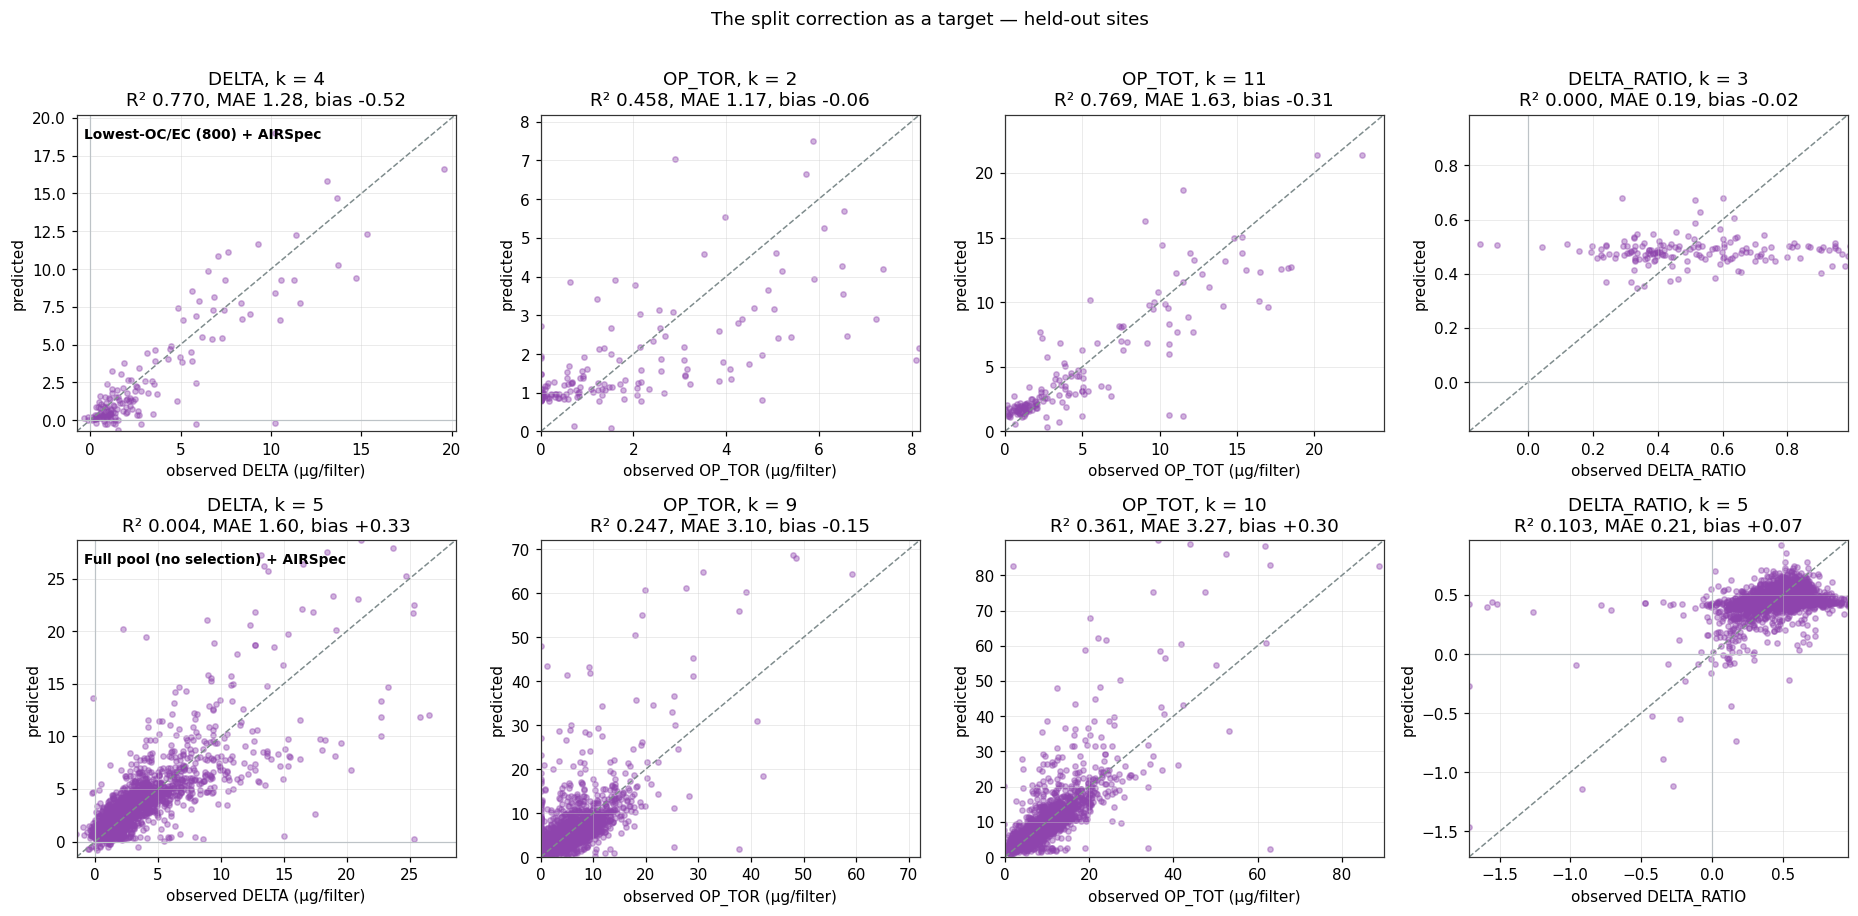

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8.2))
split_targets = ['DELTA', 'OP_TOR', 'OP_TOT', 'DELTA_RATIO']
for r, (cohort_name, ids) in enumerate(COHORTS.items()):
    X = spectra_for(ids)
    sites = pool.loc[ids, 'Site'].to_numpy()
    test = ~protocol_train_mask(MODE, X, pool.loc[ids, 'EC_TOR'].to_numpy(float), sites)
    for c, target in enumerate(split_targets):
        ax = axes[r, c]
        fit = fits[(cohort_name, target)]
        obs = pool.loc[ids[test], target].to_numpy(float)
        pred = fit.model.predict(X[test]).ravel()
        ax.scatter(obs, pred, s=12, alpha=0.4, color='#8E44AD')
        lo = min(0.0, np.quantile(obs, 0.005), np.quantile(pred, 0.005))
        hi = max(np.quantile(obs, 0.995), np.quantile(pred, 0.995))
        ax.plot([lo, hi], [lo, hi], color='#7F8C8D', ls='--', lw=1)
        ax.axhline(0, color='#BDC3C7', lw=0.8)
        ax.axvline(0, color='#BDC3C7', lw=0.8)
        unit = '' if target == 'DELTA_RATIO' else ' (µg/filter)'
        ax.set(xlim=(lo, hi), ylim=(lo, hi), xlabel=f'observed {target}{unit}',
               ylabel='predicted',
               title=f"{target}, k = {fit.k}\nR² {fit.heldout['R2']:.3f}, "
                     f"MAE {fit.heldout['MAE']:.2f}, bias {fit.heldout['bias']:+.2f}")
    axes[r, 0].annotate(cohort_name, (0.02, 0.96), xycoords='axes fraction',
                        fontsize=9, va='top', fontweight='bold')
fig.suptitle('The split correction as a target — held-out sites', y=1.01)
fig.tight_layout()
fig.savefig(PLOTS / 'split_targets_heldout.png', bbox_inches='tight')
plt.show()

### 3. Four routes to EC_TOT on the identical held-out sites

All routes are scored on the same held-out filters against the same EC_TOT truth.
Route (d) uses the true Δ, so its error is exactly the EC_TOR model's error — it is the
ceiling any composed route can reach, and its distance from the truth is the *carbon*
part of the difficulty. The distance between (b) and (d) is the *correction* part.

In [7]:
route_rows, site_rows, route_frames, rescale_rows = [], [], {}, []
for cohort_name, ids in COHORTS.items():
    X = spectra_for(ids)
    sites = pool.loc[ids, 'Site'].to_numpy()
    train = protocol_train_mask(MODE, X, pool.loc[ids, 'EC_TOR'].to_numpy(float), sites)
    test = ~train
    f = {t: fits[(cohort_name, t)] for t in TARGETS}

    # route (c): the rescale a is fitted on the training side only
    tor_hat_train = f['EC_TOR'].model.predict(X[train]).ravel()
    tot_train = pool.loc[ids[train], 'EC_TOT'].to_numpy(float)
    a_ls = float(np.sum(tor_hat_train * tot_train) / np.sum(tor_hat_train ** 2))
    a_median = float(np.median(tot_train / pool.loc[ids[train], 'EC_TOR'].to_numpy(float)))
    rescale_rows.append({'cohort': cohort_name, 'a_ls_through_origin': a_ls,
                         'training_median_EC_TOT_over_EC_TOR': a_median})

    obs = {t: pool.loc[ids[test], t].to_numpy(float) for t in TARGETS}
    pred = {t: f[t].model.predict(X[test]).ravel() for t in TARGETS}
    routes = {
        '(a) direct EC_TOT model': pred['EC_TOT'],
        '(b) composed EC_TOR_hat − DELTA_hat': pred['EC_TOR'] - pred['DELTA'],
        '(c) rescaled a·EC_TOR_hat': a_ls * pred['EC_TOR'],
        '(d) oracle EC_TOR_hat − DELTA_true': pred['EC_TOR'] - obs['DELTA'],
        '(e) ratio EC_TOR_hat·(1 − DELTA_RATIO_hat)': pred['EC_TOR'] * (1 - pred['DELTA_RATIO']),
    }
    y_true = obs['EC_TOT']
    frame = pd.DataFrame({'EC_TOT_obs': y_true, 'Site': sites[test], **routes})
    route_frames[cohort_name] = frame
    for route, yhat in routes.items():
        m = regression_metrics(y_true, yhat)
        route_rows.append({'cohort': cohort_name, 'route': route, 'n_test': m['n'],
                           'R2': m['R2'], 'slope': m['slope'], 'RMSE_ug': m['RMSE'],
                           'pct_RMSE': 100 * m['RMSE'] / y_true.mean(),
                           'bias_ug': m['bias'], 'MAE_ug': m['MAE']})
        for site, part in frame.groupby('Site'):
            err = part[route] - part['EC_TOT_obs']
            r2 = (np.corrcoef(part['EC_TOT_obs'], part[route])[0, 1] ** 2
                  if len(part) >= 3 and part['EC_TOT_obs'].std() > 0 else np.nan)
            site_rows.append({'cohort': cohort_name, 'site': site, 'n': len(part),
                              'EC_TOT_mean_ug': part['EC_TOT_obs'].mean(), 'route': route,
                              'R2': r2, 'RMSE_ug': float(np.sqrt(np.mean(err ** 2))),
                              'bias_ug': float(err.mean()), 'MAE_ug': float(err.abs().mean())})

routes_table = pd.DataFrame(route_rows)
routes_table.to_csv(OUT / 'ec_tot_routes.csv', index=False)
per_site = pd.DataFrame(site_rows)
per_site.to_csv(OUT / 'ec_tot_routes_per_site.csv', index=False)
rescale = pd.DataFrame(rescale_rows)
rescale.to_csv(OUT / 'rescale_factor.csv', index=False)
display(rescale.round(3))
display(routes_table.round(3))

,cohort,a_ls_through_origin,training_median_EC_TOT_over_EC_TOR
0,Lowest-OC/EC (800) + AIRSpec,0.511,0.551
1,Full pool (no selection) + AIRSpec,0.484,0.522


,cohort,route,n_test,R2,slope,RMSE_ug,pct_RMSE,bias_ug,MAE_ug
0,Lowest-OC/EC (800) + AIRSpec,(a) direct EC_TOT model,160,0.764,0.967,3.066,69.386,0.850,2.170
1,Lowest-OC/EC (800) + AIRSpec,(b) composed EC_TOR_hat − DELTA_hat,160,0.774,0.963,2.952,66.805,0.753,2.095
2,Lowest-OC/EC (800) + AIRSpec,(c) rescaled a·EC_TOR_hat,160,0.792,0.790,2.510,56.807,-0.302,1.620
3,Lowest-OC/EC (800) + AIRSpec,(d) oracle EC_TOR_hat − DELTA_true,160,0.697,0.946,3.426,77.518,0.234,2.113
4,Lowest-OC/EC (800) + AIRSpec,(e) ratio EC_TOR_hat·(1 − DELTA_RATIO_hat),160,0.802,0.853,2.456,55.570,-0.173,1.576
5,Full pool (no selection) + AIRSpec,(a) direct EC_TOT model,2212,0.182,0.137,9.283,197.467,-1.119,2.765
6,Full pool (no selection) + AIRSpec,(b) composed EC_TOR_hat − DELTA_hat,2212,0.684,0.369,6.907,146.933,-0.676,2.084
7,Full pool (no selection) + AIRSpec,(c) rescaled a·EC_TOR_hat,2212,0.589,0.317,7.488,159.283,-1.064,2.159
8,Full pool (no selection) + AIRSpec,(d) oracle EC_TOR_hat − DELTA_true,2212,0.773,1.010,5.546,117.980,-0.344,2.649
9,Full pool (no selection) + AIRSpec,(e) ratio EC_TOR_hat·(1 − DELTA_RATIO_hat),2212,0.786,0.959,5.115,108.801,-0.587,2.087


#### Where the composed error comes from

The composed route's error is `e_TOR − e_Δ`, so its mean-square error decomposes into
the EC_TOR model's MSE, the Δ model's MSE and twice their error covariance. The
oracle's error is `e_TOR` alone.

In [8]:
decomp_rows = []
for cohort_name, ids in COHORTS.items():
    X = spectra_for(ids)
    sites = pool.loc[ids, 'Site'].to_numpy()
    test = ~protocol_train_mask(MODE, X, pool.loc[ids, 'EC_TOR'].to_numpy(float), sites)
    e_tor = fits[(cohort_name, 'EC_TOR')].model.predict(X[test]).ravel() \
        - pool.loc[ids[test], 'EC_TOR'].to_numpy(float)
    e_delta = fits[(cohort_name, 'DELTA')].model.predict(X[test]).ravel() \
        - pool.loc[ids[test], 'DELTA'].to_numpy(float)
    e_direct = fits[(cohort_name, 'EC_TOT')].model.predict(X[test]).ravel() \
        - pool.loc[ids[test], 'EC_TOT'].to_numpy(float)
    e_comp = e_tor - e_delta
    mse_comp = float(np.mean(e_comp ** 2))
    decomp_rows.append({
        'cohort': cohort_name,
        'MSE_composed': mse_comp,
        'MSE_EC_TOR_model (= oracle)': float(np.mean(e_tor ** 2)),
        'MSE_DELTA_model': float(np.mean(e_delta ** 2)),
        'minus_2cov': float(-2 * np.mean(e_tor * e_delta)),
        'corr_errors': float(np.corrcoef(e_tor, e_delta)[0, 1]),
        'MSE_direct': float(np.mean(e_direct ** 2)),
        'delta_share_of_composed_MSE': float(1 - np.mean(e_tor ** 2) / mse_comp),
    })
decomp = pd.DataFrame(decomp_rows)
decomp.to_csv(OUT / 'composed_error_decomposition.csv', index=False)
display(decomp.round(3))

,cohort,MSE_composed,MSE_EC_TOR_model (= oracle),MSE_DELTA_model,minus_2cov,corr_errors,MSE_direct,delta_share_of_composed_MSE
0,Lowest-OC/EC (800) + AIRSpec,8.715,11.734,4.053,-7.073,0.550,9.401,-0.346
1,Full pool (no selection) + AIRSpec,47.708,30.758,72.478,-55.529,0.592,86.166,0.355


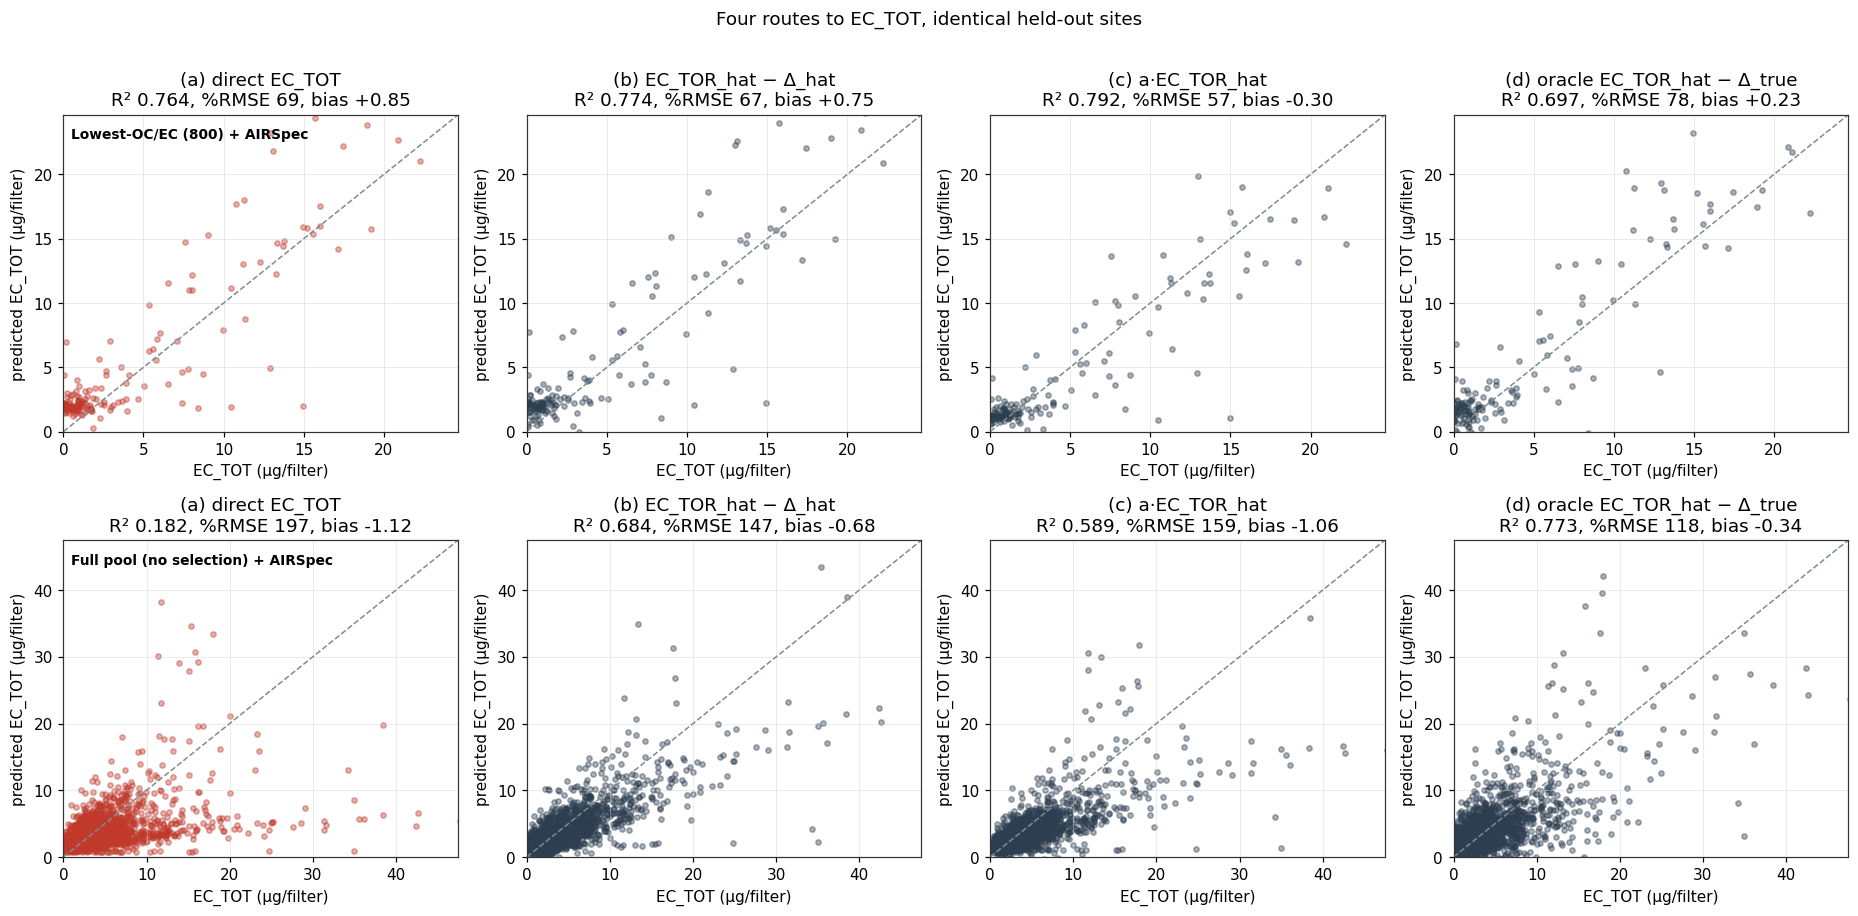

In [9]:
ROUTE_COLS = ['(a) direct EC_TOT model', '(b) composed EC_TOR_hat − DELTA_hat',
              '(c) rescaled a·EC_TOR_hat', '(d) oracle EC_TOR_hat − DELTA_true']
short_titles = ['(a) direct EC_TOT', '(b) EC_TOR_hat − Δ_hat', '(c) a·EC_TOR_hat',
                '(d) oracle EC_TOR_hat − Δ_true']
fig, axes = plt.subplots(2, 4, figsize=(17, 8.2))
for r, cohort_name in enumerate(COHORTS):
    frame = route_frames[cohort_name]
    hi = max(frame['EC_TOT_obs'].quantile(0.995),
             max(frame[c].quantile(0.995) for c in ROUTE_COLS))
    for c, (col, title) in enumerate(zip(ROUTE_COLS, short_titles)):
        ax = axes[r, c]
        m = routes_table[routes_table['cohort'].eq(cohort_name)
                         & routes_table['route'].eq(col)].iloc[0]
        ax.scatter(frame['EC_TOT_obs'], frame[col], s=12, alpha=0.4,
                   color='#C0392B' if c == 0 else '#2C3E50')
        ax.plot([0, hi], [0, hi], color='#7F8C8D', ls='--', lw=1)
        ax.set(xlim=(0, hi), ylim=(0, hi), xlabel='EC_TOT (µg/filter)',
               ylabel='predicted EC_TOT (µg/filter)',
               title=f"{title}\nR² {m['R2']:.3f}, %RMSE {m['pct_RMSE']:.0f}, "
                     f"bias {m['bias_ug']:+.2f}")
    axes[r, 0].annotate(cohort_name, (0.02, 0.96), xycoords='axes fraction',
                        fontsize=9, va='top', fontweight='bold')
fig.suptitle('Four routes to EC_TOT, identical held-out sites', y=1.01)
fig.tight_layout()
fig.savefig(PLOTS / 'ec_tot_routes_crossplots.png', bbox_inches='tight')
plt.show()

In [10]:
cohort0 = 'Lowest-OC/EC (800) + AIRSpec'
ps = per_site[per_site['cohort'].eq(cohort0) & per_site['route'].isin(ROUTE_COLS)]
ps_wide = ps.pivot(index='site', columns='route', values='RMSE_ug').loc[:, ROUTE_COLS]
ps_wide.insert(0, 'n', ps.groupby('site')['n'].first())
ps_wide.insert(1, 'EC_TOT_mean_ug', ps.groupby('site')['EC_TOT_mean_ug'].first())
print(f'{cohort0}: held-out-site RMSE (µg/filter) by route')
display(ps_wide.round(2))

Lowest-OC/EC (800) + AIRSpec: held-out-site RMSE (µg/filter) by route


route,n,EC_TOT_mean_ug,(a) direct EC_TOT model,(b) composed EC_TOR_hat − DELTA_hat,(c) rescaled a·EC_TOR_hat,(d) oracle EC_TOR_hat − DELTA_true
site,,,,,,
CANY1,3,1.38,0.39,0.32,0.75,2.11
CHAS1,7,12.96,5.24,5.28,5.87,9.52
DOME1,4,2.64,1.37,1.64,1.63,3.20
FOCO1,2,8.56,5.54,6.22,5.60,6.81
FOCO2,2,5.03,2.41,2.82,2.20,1.99
GRGU1,3,0.57,1.84,1.57,0.99,1.70
JARI1,4,3.67,1.47,1.53,0.88,1.48
KALM1,1,0.21,2.50,2.64,1.32,2.14
LOST1,5,2.68,3.64,2.68,2.02,3.70


### 4. Adama: five quartz filters with OP_TOR and OP_TOT measured directly

The Adama PTFE spectra go through ftir_44's pipeline unchanged — AIRSpec df1 = 6
baseline on the pool's analyzed grid, id → filter map validated on the CH-band/OC rank
test — and the Δ models (trained only on IMPROVE) are applied to them. Measured Δ is
the quartz `OPTT − OPTR` concentration on the date-paired filter.

In [11]:
spectra = pd.read_csv(AMOD / 'csu_amod_Batch_54_ShipDate_2026-05-29_spectra.csv')
spectra = spectra.rename(columns={'Wavelength': 'SampleAnalysisId'}).set_index('SampleAnalysisId')
wn_adama = np.array([float(c) for c in spectra.columns])

ftir = pd.read_csv(AMOD / 'csu_amod_FTIR_Batch_54.csv', encoding='cp1252')
ftir['analysis_time'] = pd.to_datetime(ftir['AnalysisDate'] + ' ' + ftir['AnalysisTime'])
ptfe = (ftir.pivot_table(index=['FilterId', 'SampleDate', 'Volume_m3', 'analysis_time'],
                         columns='Parameter', values='Concentration_ug_m3').reset_index())
ptfe.columns.name = None
ptfe['OC_loading_ug'] = ftir[ftir['Parameter'].eq('OC_ftir')].set_index('FilterId')\
    .loc[ptfe['FilterId'], 'MassLoading_ug'].to_numpy()
ptfe['date'] = pd.to_datetime(ptfe['SampleDate']).dt.normalize()

wn_pool = corrected_npz['wn'].astype(float)
desc = np.argsort(-wn_adama)
x = wn_adama[desc]
_, corr_all = airspec_baseline_matrix(x, spectra.to_numpy(float)[:, desc], df1=6, df2=4)
analyzed = make_mask(x, SEG1) | make_mask(x, SEG2)
assert analyzed.sum() == len(wn_pool) and np.allclose(x[analyzed], wn_pool, atol=1e-3), \
    'Adama analyzed grid differs from the calibration pool grid'
corr_by_id = pd.DataFrame(corr_all[:, analyzed], index=spectra.index)
ch_by_id = corr_by_id.iloc[:, int(np.argmin(np.abs(wn_pool - 2920)))]

candidates = {
    'analysis time': ptfe.sort_values('analysis_time')['FilterId'].tolist(),
    'FilterId': sorted(ptfe['FilterId']),
    'sample date': ptfe.sort_values('SampleDate')['FilterId'].tolist(),
}
oc_by_filter = ptfe.set_index('FilterId')['OC_loading_ug']
mapping_audit = []
for name, filter_order in candidates.items():
    rho, _ = spearmanr(ch_by_id.loc[sorted(spectra.index)].to_numpy(),
                       oc_by_filter.loc[filter_order].to_numpy())
    mapping_audit.append({'ordering': name, 'spearman_CH_vs_OC': rho,
                          'id_4746_maps_to': filter_order[2]})
mapping_audit = pd.DataFrame(mapping_audit)
chosen = mapping_audit.sort_values('spearman_CH_vs_OC', ascending=False).iloc[0]
assert chosen['ordering'] == 'FilterId' and chosen['spearman_CH_vs_OC'] > 0.99, \
    'expected the FilterId ordering to be the unique perfect-rank mapping'
id_to_filter = dict(zip(sorted(spectra.index), sorted(ptfe['FilterId'])))
assert id_to_filter == {4744: 'J1233', 4745: 'J1266', 4746: 'J1269', 4747: 'J1270', 4748: 'J1285'}, \
    f'id → filter map changed: {id_to_filter}'
ptfe['SampleAnalysisId'] = ptfe['FilterId'].map({v: k for k, v in id_to_filter.items()})

quartz = pd.read_csv(ADAMA / 'Carbon_concs_Batch54.csv')
quartz['date'] = pd.to_datetime(quartz['SampleDate']).dt.normalize()
quartz = quartz.pivot_table(index=['FilterId', 'date'], columns='Parameter',
                            values='Concentration_ug_m3').reset_index()
quartz.columns.name = None
quartz['DELTA_meas'] = quartz['OPTT'] - quartz['OPTR']
assert np.allclose(quartz['ECTR'] + quartz['OPTR'] - quartz['OPTT'], quartz['ECTT'], atol=1e-3), \
    "lab ECTT is not ECTR + OPTR − OPTT"
print('max |ECTT − (ECTR + OPTR − OPTT)| on Adama: '
      f"{np.abs(quartz['ECTR'] + quartz['OPTR'] - quartz['OPTT'] - quartz['ECTT']).max():.1e} µg/m³")

pairs = (ptfe.merge(quartz, on='date', suffixes=('_ptfe', '_quartz'))
             .sort_values('date').reset_index(drop=True))
pairs['flag'] = ''
pairs.loc[pairs['date'].eq('2024-07-09'), 'flag'] = 'start-offset'
pairs.loc[pairs['date'].eq('2024-07-30'), 'flag'] = 'volume-mismatch'
X_adama = corr_by_id.loc[pairs['SampleAnalysisId']].to_numpy(float)
volume_adama = pairs['Volume_m3'].to_numpy(float)
flagged = pairs['flag'].ne('').to_numpy()
print(f'Adama corrected spectra: {X_adama.shape}; {int(flagged.sum())} of 5 flagged')

max |ECTT − (ECTR + OPTR − OPTT)| on Adama: 1.3e-04 µg/m³
Adama corrected spectra: (5, 2002); 2 of 5 flagged


In [12]:
adama = pairs[['date', 'FilterId_ptfe', 'SampleAnalysisId', 'FilterId_quartz', 'flag',
               'OPTR', 'OPTT', 'DELTA_meas', 'ECTR', 'ECTT']].copy()
adama['DELTA_over_ECTR_meas'] = adama['DELTA_meas'] / adama['ECTR']
tag = {'Lowest-OC/EC (800) + AIRSpec': '800', 'Full pool (no selection) + AIRSpec': 'full'}
for cohort_name, ids in COHORTS.items():
    t = tag[cohort_name]
    for target in ('DELTA', 'OP_TOR', 'OP_TOT', 'EC_TOR', 'EC_TOT'):
        adama[f'{target}_hat_{t}'] = (fits[(cohort_name, target)].model.predict(X_adama).ravel()
                                       / volume_adama)
    adama[f'DELTA_pred_over_meas_{t}'] = adama[f'DELTA_hat_{t}'] / adama['DELTA_meas']
    adama[f'EC_TOT_composed_{t}'] = adama[f'EC_TOR_hat_{t}'] - adama[f'DELTA_hat_{t}']
adama.to_csv(OUT / 'adama_delta_check.csv', index=False)
show_cols = ['date', 'FilterId_ptfe', 'flag', 'OPTR', 'OPTT', 'DELTA_meas', 'DELTA_over_ECTR_meas',
             'DELTA_hat_800', 'DELTA_pred_over_meas_800', 'DELTA_hat_full', 'DELTA_pred_over_meas_full',
             'ECTT', 'EC_TOT_hat_800', 'EC_TOT_composed_800']
display(adama[show_cols].round(3))
adama_medians = {
    'DELTA_pred_over_meas_800 (unflagged median)': float(adama.loc[~flagged, 'DELTA_pred_over_meas_800'].median()),
    'DELTA_pred_over_meas_800 (all 5 median)': float(adama['DELTA_pred_over_meas_800'].median()),
    'DELTA_pred_over_meas_full (unflagged median)': float(adama.loc[~flagged, 'DELTA_pred_over_meas_full'].median()),
    'DELTA_over_ECTR_meas (median of 5)': float(adama['DELTA_over_ECTR_meas'].median()),
    'IMPROVE DELTA_RATIO median (800 cohort)': float(pool.loc[ocec_ids, 'DELTA_RATIO'].median()),
    'EC_TOT_composed_800 / ECTT (unflagged median)': float((adama['EC_TOT_composed_800'] / adama['ECTT'])[~flagged].median()),
    'EC_TOT_hat_800 / ECTT (unflagged median)': float((adama['EC_TOT_hat_800'] / adama['ECTT'])[~flagged].median()),
}
adama_med = pd.Series(adama_medians)
adama_med.to_csv(OUT / 'adama_delta_medians.csv', header=['value'])
print(adama_med.round(3))

,date,FilterId_ptfe,flag,OPTR,OPTT,DELTA_meas,DELTA_over_ECTR_meas,DELTA_hat_800,DELTA_pred_over_meas_800,DELTA_hat_full,DELTA_pred_over_meas_full,ECTT,EC_TOT_hat_800,EC_TOT_composed_800
0,2024-07-09,J1269,start-offset,1.989,2.631,0.642,0.190,0.472,0.735,1.718,2.676,2.737,7.176,7.781
1,2024-07-20,J1266,,1.239,1.690,0.451,0.188,0.180,0.399,0.501,1.111,1.947,2.231,2.680
2,2024-07-23,J1285,,1.544,2.050,0.505,0.206,0.206,0.407,0.608,1.203,1.944,2.476,2.901
3,2024-07-26,J1233,,1.124,1.489,0.364,0.196,0.147,0.404,0.455,1.247,1.497,1.999,2.371
4,2024-07-30,J1270,volume-mismatch,1.521,1.990,0.468,0.154,0.278,0.593,0.793,1.693,2.573,3.509,4.086


DELTA_pred_over_meas_800 (unflagged median)      0.404
DELTA_pred_over_meas_800 (all 5 median)          0.407
DELTA_pred_over_meas_full (unflagged median)     1.203
DELTA_over_ECTR_meas (median of 5)               0.190
IMPROVE DELTA_RATIO median (800 cohort)          0.454
EC_TOT_composed_800 / ECTT (unflagged median)    1.492
EC_TOT_hat_800 / ECTT (unflagged median)         1.274
dtype: float64


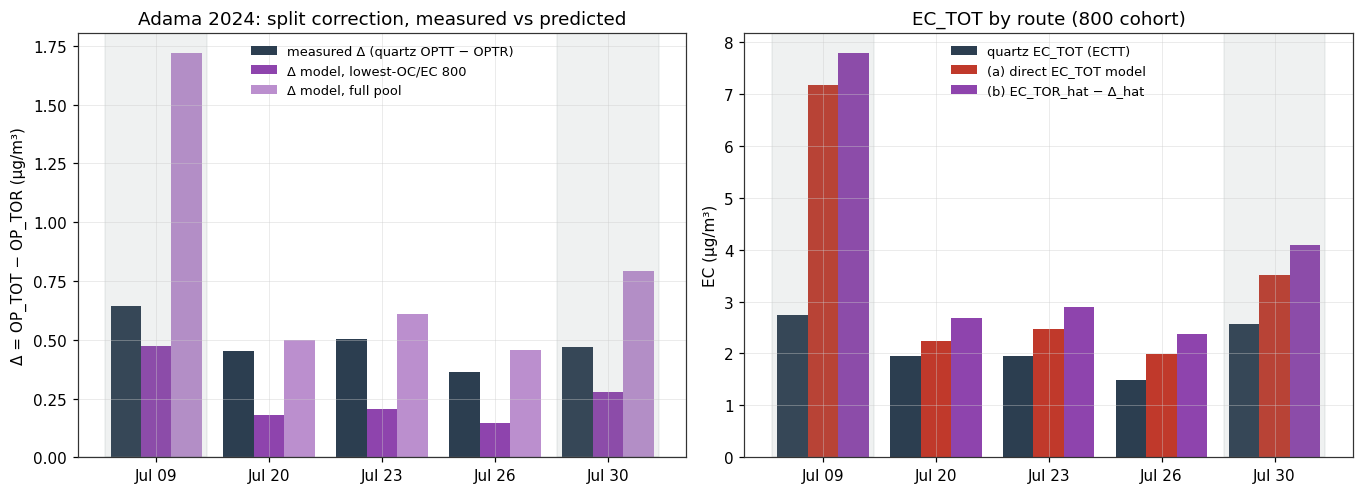

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
xpos = np.arange(len(adama))
dates = adama['date'].dt.strftime('%b %d')
width = 0.27
ax = axes[0]
ax.bar(xpos - width, adama['DELTA_meas'], width, color='#2C3E50', label='measured Δ (quartz OPTT − OPTR)')
ax.bar(xpos, adama['DELTA_hat_800'], width, color='#8E44AD', label='Δ model, lowest-OC/EC 800')
ax.bar(xpos + width, adama['DELTA_hat_full'], width, color='#BB8FCE', label='Δ model, full pool')
ax.axhline(0, color='#7F8C8D', lw=0.8)
for i in np.where(flagged)[0]:
    ax.axvspan(i - 0.45, i + 0.45, color='#7F8C8D', alpha=0.12)
ax.set(xticks=xpos, xticklabels=dates, ylabel='Δ = OP_TOT − OP_TOR (µg/m³)',
       title='Adama 2024: split correction, measured vs predicted')
ax.legend(frameon=False, fontsize=8.5)
ax = axes[1]
ax.bar(xpos - width, adama['ECTT'], width, color='#2C3E50', label='quartz EC_TOT (ECTT)')
ax.bar(xpos, adama['EC_TOT_hat_800'], width, color='#C0392B', label='(a) direct EC_TOT model')
ax.bar(xpos + width, adama['EC_TOT_composed_800'], width, color='#8E44AD', label='(b) EC_TOR_hat − Δ_hat')
for i in np.where(flagged)[0]:
    ax.axvspan(i - 0.45, i + 0.45, color='#7F8C8D', alpha=0.12)
ax.set(xticks=xpos, xticklabels=dates, ylabel='EC (µg/m³)', title='EC_TOT by route (800 cohort)')
ax.legend(frameon=False, fontsize=8.5)
fig.tight_layout()
fig.savefig(PLOTS / 'adama_delta_check.png', bbox_inches='tight')
plt.show()

### 5. Addis: the composed route against the direct EC_TOT model

With f(X) fixed, the EC_TOT-equivalent for Addis is `EC_TOR_hat − Δ_hat`, both models
predicted on the Addis spectra. Crossplot against HIPS Fabs/10 on the fixed evaluation
set; ftir_42's direct EC_TOT (0.63x − 1.24) and EC_TOR (0.81x − 1.53) lines are
reproduced and asserted.

In [14]:
addis_rows = []
hips_ec = fabs[fixed_mask] / MAC_HEADLINE
for cohort_name in COHORTS:
    f = {t: fits[(cohort_name, t)] for t in TARGETS}
    a_ls = rescale.set_index('cohort').loc[cohort_name, 'a_ls_through_origin']
    addis_routes = {
        'EC_TOR model (ftir_42)': f['EC_TOR'].addis_ugm3,
        '(a) direct EC_TOT model (ftir_42)': f['EC_TOT'].addis_ugm3,
        '(b) composed EC_TOR_hat − DELTA_hat': f['EC_TOR'].addis_ugm3 - f['DELTA'].addis_ugm3,
        '(c) rescaled a·EC_TOR_hat': a_ls * f['EC_TOR'].addis_ugm3,
        'DELTA model alone': f['DELTA'].addis_ugm3,
    }
    for route, pred_all in addis_routes.items():
        pred = pred_all[fixed_mask]
        ols = regression_metrics(hips_ec, pred)
        dem = calculate_regression_stats(hips_ec, pred, errors_in_variables=True,
                                         sigma_x=0.308, sigma_y=0.531)
        addis_rows.append({
            'cohort': cohort_name, 'route': route, 'n': ols['n'],
            'slope': ols['slope'], 'intercept': ols['intercept'],
            'deming_slope': dem['deming_slope'], 'deming_intercept': dem['deming_intercept'],
            'R2': ols['R2'], 'RMSE': ols['RMSE'],
            'median_pred_ugm3': float(np.median(pred)),
            'median_ratio_to_EC_TOR_model': float(np.median(pred / addis_routes['EC_TOR model (ftir_42)'][fixed_mask])),
        })
addis_table = pd.DataFrame(addis_rows)
addis_table.to_csv(OUT / 'addis_ec_tot_routes.csv', index=False)
display(addis_table.round(3))

ref42 = pd.read_csv('output/tables/ftir42/addis_by_ec_convention.csv')
for target, route in (('EC_TOR', 'EC_TOR model (ftir_42)'), ('EC_TOT', '(a) direct EC_TOT model (ftir_42)')):
    r = ref42[ref42['cohort'].eq(f'{cohort0} → {target}')].iloc[0]
    m = addis_table[addis_table['cohort'].eq(cohort0) & addis_table['route'].eq(route)].iloc[0]
    assert abs(m['slope'] - r['slope']) < 1e-6 and abs(m['intercept'] - r['intercept']) < 1e-6, \
        f'Addis {target} line drifted from ftir_42'
print('Addis EC_TOR and direct EC_TOT lines reproduce ftir_42 exactly.')

,cohort,route,n,slope,intercept,deming_slope,deming_intercept,R2,RMSE,median_pred_ugm3,median_ratio_to_EC_TOR_model
0,Lowest-OC/EC (800) + AIRSpec,EC_TOR model (ftir_42),190,0.811,-1.527,0.907,-1.997,0.626,2.549,2.239,1.000
1,Lowest-OC/EC (800) + AIRSpec,(a) direct EC_TOT model (ftir_42),190,0.632,-1.242,0.677,-1.461,0.639,3.107,1.665,0.760
2,Lowest-OC/EC (800) + AIRSpec,(b) composed EC_TOR_hat − DELTA_hat,190,0.676,-1.378,0.724,-1.610,0.668,3.023,1.757,0.792
3,Lowest-OC/EC (800) + AIRSpec,(c) rescaled a·EC_TOR_hat,190,0.414,-0.780,0.428,-0.849,0.626,3.711,1.145,0.511
4,Lowest-OC/EC (800) + AIRSpec,DELTA model alone,190,0.134,-0.149,0.136,-0.157,0.326,4.479,0.482,0.208
5,Full pool (no selection) + AIRSpec,EC_TOR model (ftir_42),190,0.461,-0.690,0.478,-0.774,0.649,3.394,1.385,1.000
6,Full pool (no selection) + AIRSpec,(a) direct EC_TOT model (ftir_42),190,0.075,-0.002,0.075,-0.002,0.578,4.626,0.346,0.246
7,Full pool (no selection) + AIRSpec,(b) composed EC_TOR_hat − DELTA_hat,190,0.313,-0.499,0.318,-0.524,0.669,3.930,0.917,0.661
8,Full pool (no selection) + AIRSpec,(c) rescaled a·EC_TOR_hat,190,0.223,-0.334,0.225,-0.344,0.649,4.217,0.669,0.484
9,Full pool (no selection) + AIRSpec,DELTA model alone,190,0.147,-0.191,0.148,-0.195,0.570,4.453,0.485,0.339


Addis EC_TOR and direct EC_TOT lines reproduce ftir_42 exactly.


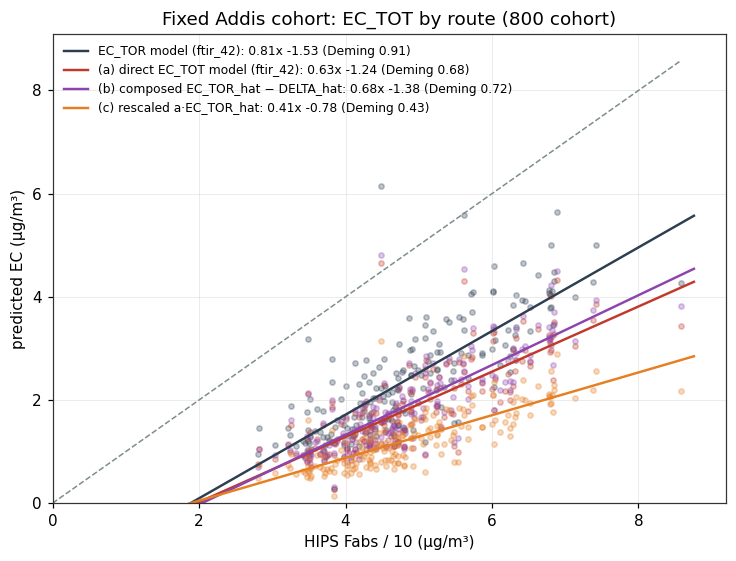

In [15]:
fig, ax = plt.subplots(figsize=(6.8, 5.2))
colors = {'EC_TOR model (ftir_42)': '#2C3E50', '(a) direct EC_TOT model (ftir_42)': '#C0392B',
          '(b) composed EC_TOR_hat − DELTA_hat': '#8E44AD', '(c) rescaled a·EC_TOR_hat': '#E67E22'}
f = {t: fits[(cohort0, t)] for t in TARGETS}
a_ls = rescale.set_index('cohort').loc[cohort0, 'a_ls_through_origin']
series = {'EC_TOR model (ftir_42)': f['EC_TOR'].addis_ugm3[fixed_mask],
          '(a) direct EC_TOT model (ftir_42)': f['EC_TOT'].addis_ugm3[fixed_mask],
          '(b) composed EC_TOR_hat − DELTA_hat': (f['EC_TOR'].addis_ugm3 - f['DELTA'].addis_ugm3)[fixed_mask],
          '(c) rescaled a·EC_TOR_hat': a_ls * f['EC_TOR'].addis_ugm3[fixed_mask]}
xs = np.linspace(0, hips_ec.max() * 1.02, 10)
for route, pred in series.items():
    m = addis_table[addis_table['cohort'].eq(cohort0) & addis_table['route'].eq(route)].iloc[0]
    ax.scatter(hips_ec, pred, s=12, alpha=0.3, color=colors[route])
    ax.plot(xs, m['slope'] * xs + m['intercept'], color=colors[route], lw=1.6,
            label=f"{route}: {m['slope']:.2f}x {m['intercept']:+.2f} (Deming {m['deming_slope']:.2f})")
ax.plot([0, hips_ec.max()], [0, hips_ec.max()], color='#7F8C8D', ls='--', lw=1)
ax.set(xlim=(0, None), ylim=(0, None), xlabel=f'HIPS Fabs / {MAC_HEADLINE:.0f} (µg/m³)',
       ylabel='predicted EC (µg/m³)', title='Fixed Addis cohort: EC_TOT by route (800 cohort)')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(PLOTS / 'addis_ec_tot_routes.png', bbox_inches='tight')
plt.show()

## Takeaways

- **The reviewer's question has a two-part answer.** On the composition-selected cohort,
  the pyrolysis split is *not* what makes EC_TOT hard: a model that knows Δ exactly does
  no better than one that ignores it, because every route inherits the same ~3 µg/filter
  carbon error from the EC_TOR side. EC_TOT's worse R² and %RMSE are the arithmetic of
  a smaller target with the same absolute error. On the unselected pool the split *is*
  part of the problem (Δ unlearnable, 36% of the composed MSE) — which is the
  composition-dependence ftir_42 and ftir_44 already flagged, seen from the Δ side.
- **Composition, not the model, is the useful lever.** The direct EC_TOT model's full-pool
  collapse (k = 2, R² 0.18) is a modelling failure the composed route avoids (R² 0.68)
  without any new information; when a single-target PLS is asked to learn EC minus a
  term it cannot see, it under-fits both. Fitting EC_TOR and Δ separately and subtracting
  is the safer construction whenever EC_TOT is the convention wanted.
- **The cheapest route wins on the cohort.** a·EC_TOR_hat with a training-side a = 0.51
  beats every learned Δ (R² 0.79, %RMSE 57) — on IMPROVE-like composition the split is
  close enough to a constant fraction that a rescale captures it, and the errors that
  remain are the carbon's.
- **Adama says the fraction is not universal.** There Δ/EC_TOR is 0.19, less than half the
  cohort's 0.45, and the cohort Δ model under-reads it by 2.5×. The correction is a
  property of the OC matrix and the thermal protocol; a Δ model trained on
  low-OC/EC filters does not carry to OC/EC ≈ 6 aerosol any better than the EC models
  did in ftir_44. That also means route (c)'s a = 0.51 would over-correct Adama.
- **Addis is indifferent to the route.** Composed (0.68x − 1.38) and direct
  (0.63x − 1.24) EC_TOT-equivalents bracket each other; both sit below the EC_TOR
  line by the expected ~20–25%, and the intercept stays negative at −1.2 to −1.4.
  Nothing about the offset is a Δ-prediction artefact.

## Limits

- Δ, OP_TOR and OP_TOT are derived from the mirror's IMPROVE_A columns; the mirror
  reports them per (Site, date) and the loading conversion is ftir_42's, so any
  systematic error in that construction is inherited unchanged.
- The route comparison is on 160 held-out filters from 25 sites (cohort) and 2,212 from
  32 sites (full pool); per-site rows with n ≤ 3 are noisy and shown for completeness.
- Route (d) is an oracle, not a method: it needs a thermal analysis to produce Δ_true.
  It is used only to bound how much of the EC_TOT difficulty a perfect Δ could remove.
- Route (c)'s a is fitted on in-sample training predictions, which are less noisy than
  held-out ones; a from cross-validated training predictions would be slightly smaller.
- Adama is n = 5 with two flagged pairs and no PTFE OP measurement of its own — the
  quartz Δ is compared to a PTFE-spectrum prediction across media, as in ftir_44.
- Addis has no thermal reference; the Addis line is a crossplot against HIPS Fabs/10 on
  the fixed 190-filter set and inherits the MAC and HIPS-uncertainty assumptions of
  ftir_42 (Deming λ from σx = 0.308, σy = 0.531).